<a href="https://colab.research.google.com/github/Vivekshrotriya1/Capgemini-Training/blob/main/Deep_Learning_single_layer_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:
     Items_Ordered  Order_Size
0               1           0
1               2           0
2               3           1
3               4           1
4               2           0
5               5           1
6               6           1
7               1           0
8               3           1
9               4           1
10              2           0
11              1           0
12              5           1
13              6           1
14              3           1
15              2           0
16              4           1
17              5           1
18              1           0
19              3           1


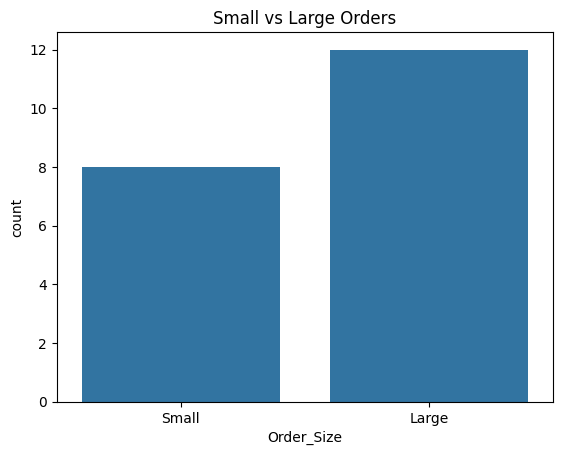

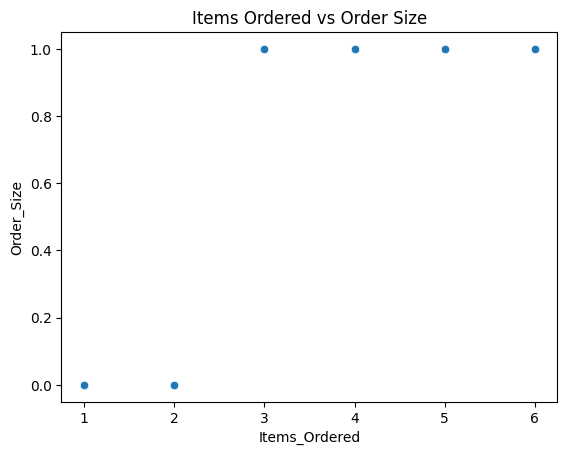

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57 (228.00 B)

 Trainable params: 57 (228.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2500 - loss: 1.0122 - val_accuracy: 0.5000 - val_loss: 0.8832
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.2500 - loss: 1.0042 - val_accuracy: 0.5000 - val_loss: 0.8785
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.2500 - loss: 0.9963 - val_accuracy: 0.5000 - val_loss: 0.8739
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.2500 - loss: 0.9884 - val_accuracy: 0.5000 - val_loss: 0.8694
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.2500 - loss: 0.9807 - val_accuracy: 0.5000 - val_loss: 0.8649
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.2500 - loss: 0.9729 - val_accuracy: 0.5000 - val_loss: 0.8604
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.2500 - loss: 0.9653 - val_accuracy: 0.5000 - val_loss: 0.8561
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.2500 - loss: 0.9577 - val_accuracy: 0.5000 - val_loss: 0.8518
E

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step

Confusion Matrix
[[2 1]
 [1 0]]

Classification Report
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.00      0.00      0.00         1

    accuracy                           0.50         4
   macro avg       0.33      0.33      0.33         4
weighted avg       0.50      0.50      0.50         4



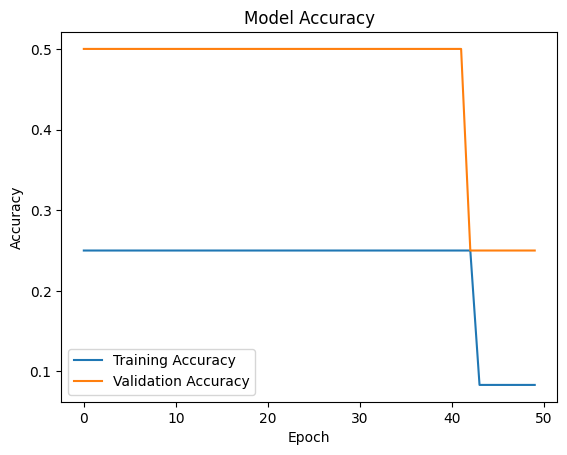

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step

Order with 4 items -> Small Order


In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


data = {
    "Items_Ordered": [1,2,3,4,2,5,6,1,3,4,2,1,5,6,3,2,4,5,1,3]
}

df = pd.DataFrame(data)


df["Order_Size"] = df["Items_Ordered"].apply(lambda x: 1 if x >= 3 else 0)

print("Dataset:\n", df)



plt.figure()
sns.countplot(x="Order_Size", data=df)
plt.title("Small vs Large Orders")
plt.xticks([0,1],["Small","Large"])
plt.show()


plt.figure()
sns.scatterplot(x="Items_Ordered", y="Order_Size", data=df)
plt.title("Items Ordered vs Order Size")
plt.show()



X = df[["Items_Ordered"]].values
y = df["Order_Size"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)




model = Sequential()

model.add(Dense(8, activation='relu', input_shape=(1,)))
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)



loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)



y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))




plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()




new_order = np.array([[4]])

prediction = model.predict(new_order)

if prediction > 0.5:
    print("\nOrder with 4 items -> Large Order")
else:
    print("\nOrder with 4 items -> Small Order")